# Imports

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

# Load Data

In [2]:
df = pd.read_csv('../data/df_working_clean.csv')

# Train/Test split

In [3]:
X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (129973, 37)
Test size:  (32494, 37)


# Baseline

=== Logistic Regression (Baseline) ===

              precision    recall  f1-score   support

           0       0.62      0.88      0.73     14691
           1       0.85      0.56      0.67     17803

    accuracy                           0.70     32494
   macro avg       0.73      0.72      0.70     32494
weighted avg       0.74      0.70      0.70     32494

ROC-AUC Score: 0.7410


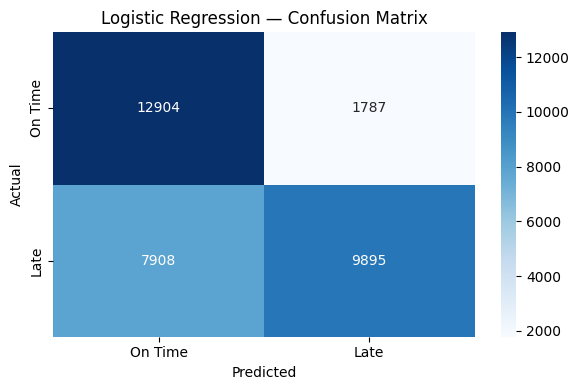

In [5]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("=== Logistic Regression (Baseline) ===\n")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Late'],
    yticklabels=['On Time', 'Late'],
    ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# XGBoost

=== XGBoost ===

              precision    recall  f1-score   support

           0       0.65      0.86      0.74     14691
           1       0.85      0.62      0.72     17803

    accuracy                           0.73     32494
   macro avg       0.75      0.74      0.73     32494
weighted avg       0.76      0.73      0.73     32494

ROC-AUC Score: 0.8279


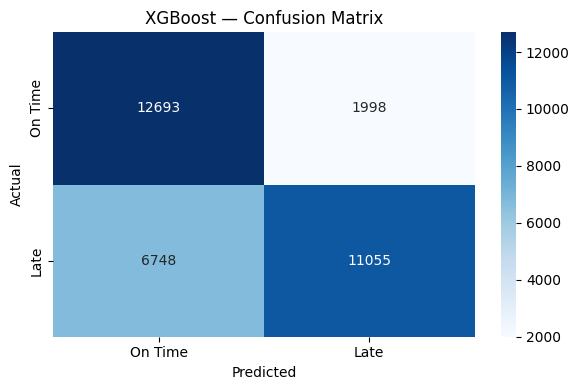

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("=== XGBoost ===\n")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Late'],
    yticklabels=['On Time', 'Late'],
    ax=ax
)
ax.set_title('XGBoost — Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# LightGBM

=== LightGBM ===

              precision    recall  f1-score   support

           0       0.64      0.87      0.74     14691
           1       0.85      0.60      0.70     17803

    accuracy                           0.72     32494
   macro avg       0.75      0.74      0.72     32494
weighted avg       0.76      0.72      0.72     32494

ROC-AUC Score: 0.8127


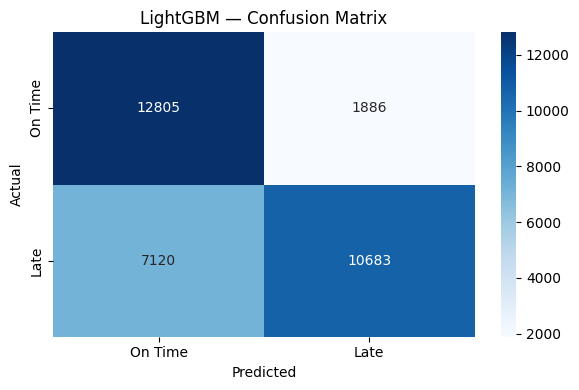

In [7]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Evaluation
print("=== LightGBM ===\n")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lgbm),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Late'],
    yticklabels=['On Time', 'Late'],
    ax=ax
)
ax.set_title('LightGBM — Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Hyperparameter tuning

In [8]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50)

print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-04-13 22:24:50,123] A new study created in memory with name: no-name-8fd01390-04f8-44ba-aed2-36ea2d15883d


Best ROC-AUC: 0.9618
Best params: {'n_estimators': 458, 'max_depth': 10, 'learning_rate': 0.23926642023147013, 'subsample': 0.9748595589970168, 'colsample_bytree': 0.7898960458771436, 'min_child_weight': 3}


# Tuned XGBoost with best parameters

In [9]:
best_xgb = XGBClassifier(
    n_estimators=458,
    max_depth=10,
    learning_rate=0.23926642023147013,
    subsample=0.9748595589970168,
    colsample_bytree=0.7898960458771436,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_xgb.fit(X_train, y_train)
y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("=== Tuned XGBoost ===\n")
print(classification_report(y_test, y_pred_best_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_best_xgb):.4f}")

=== Tuned XGBoost ===

              precision    recall  f1-score   support

           0       0.88      0.91      0.90     14691
           1       0.92      0.90      0.91     17803

    accuracy                           0.91     32494
   macro avg       0.90      0.91      0.90     32494
weighted avg       0.91      0.91      0.91     32494

ROC-AUC Score: 0.9618


# Feature importance analysis

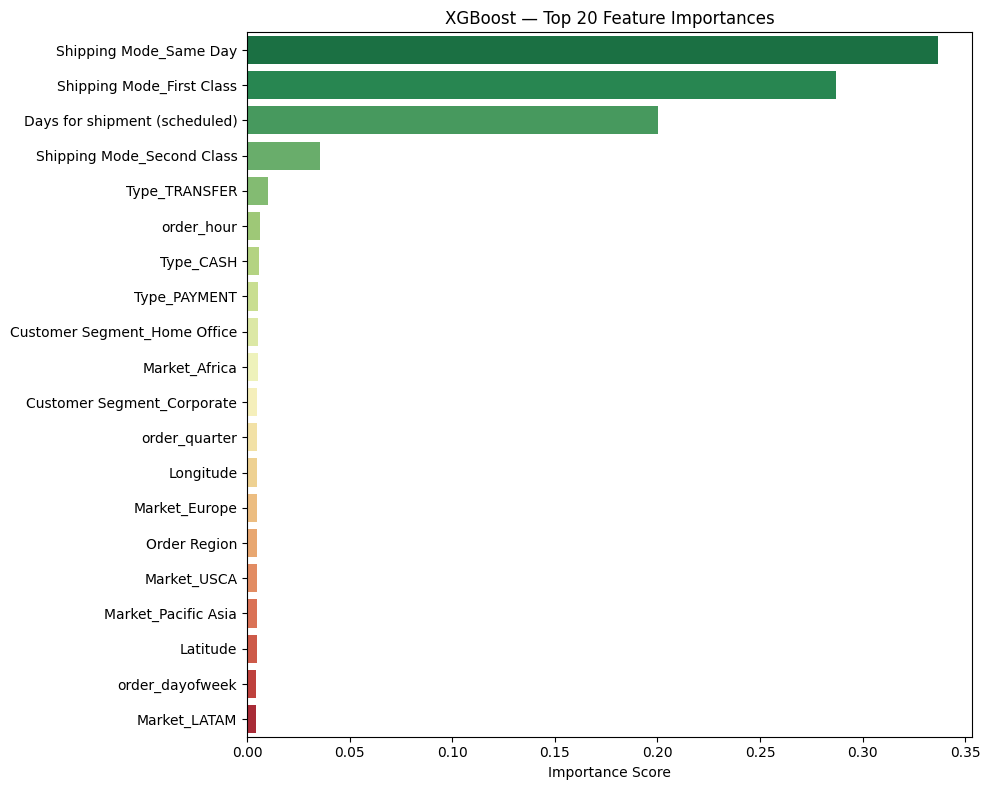

                          feature  importance
34         Shipping Mode_Same Day    0.336554
33      Shipping Mode_First Class    0.287013
0   Days for shipment (scheduled)    0.200113
35     Shipping Mode_Second Class    0.035681
18                  Type_TRANSFER    0.010093
14                     order_hour    0.006278
15                      Type_CASH    0.005879
17                   Type_PAYMENT    0.005560
21   Customer Segment_Home Office    0.005292
28                  Market_Africa    0.005178


In [12]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature',
    hue='feature',
    palette='RdYlGn_r',
    legend=False,
    ax=ax
)
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

# Deep Learning model

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Projects\Final-Project\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
# Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6607 - loss: 0.6224 - val_accuracy: 0.7127 - val_loss: 0.5472
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7034 - loss: 0.5541 - val_accuracy: 0.7159 - val_loss: 0.5346
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7116 - loss: 0.5430 - val_accuracy: 0.7169 - val_loss: 0.5308
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7157 - loss: 0.5364 - val_accuracy: 0.7174 - val_loss: 0.5275
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7164 - loss: 0.5332 - val_accuracy: 0.7171 - val_loss: 0.5269
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7174 - loss: 0.5307 - val_accuracy: 0.7174 - val_loss: 0.5261
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7178 - loss: 0.5298 - val_accuracy: 0.7170 - val_loss: 0.5256
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7182 - loss: 0.5285 - val_accuracy: 0.

In [17]:
# Evaluate
y_pred_nn = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()
y_prob_nn = model.predict(X_test_scaled).flatten()

print("=== Neural Network ===\n")
print(classification_report(y_test, y_pred_nn))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_nn):.4f}")

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step
=== Neural Network ===

              precision    recall  f1-score   support

           0       0.63      0.87      0.73     14691
           1       0.85      0.58      0.69     17803

    accuracy                           0.71     32494
   macro avg       0.74      0.73      0.71     32494
weighted avg       0.75      0.71      0.71     32494

ROC-AUC Score: 0.7729


## Training history

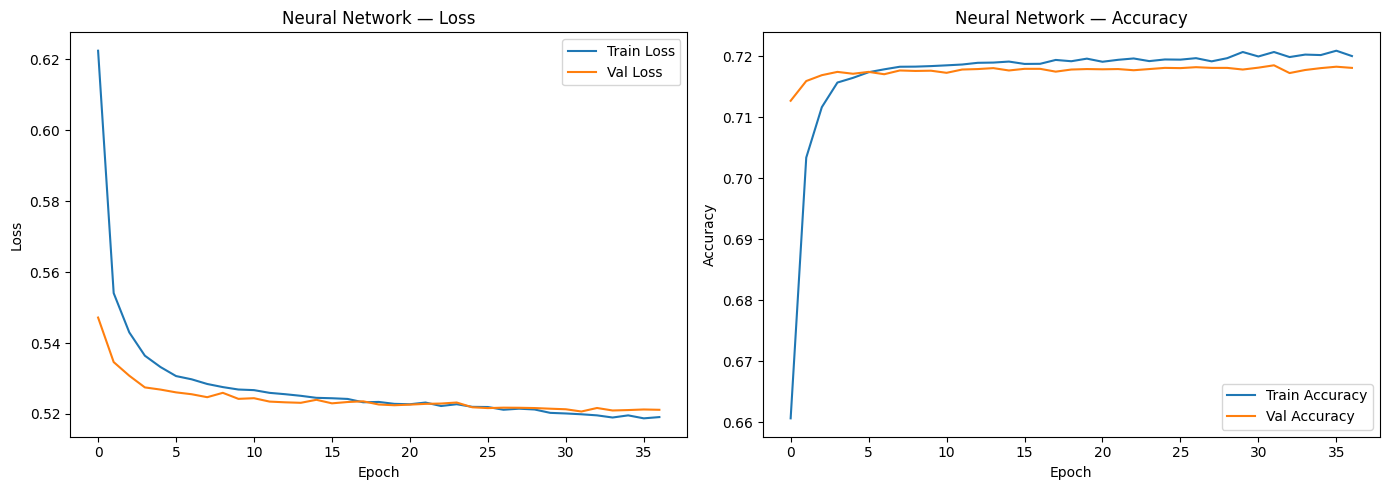

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Neural Network — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Neural Network — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Model comparison

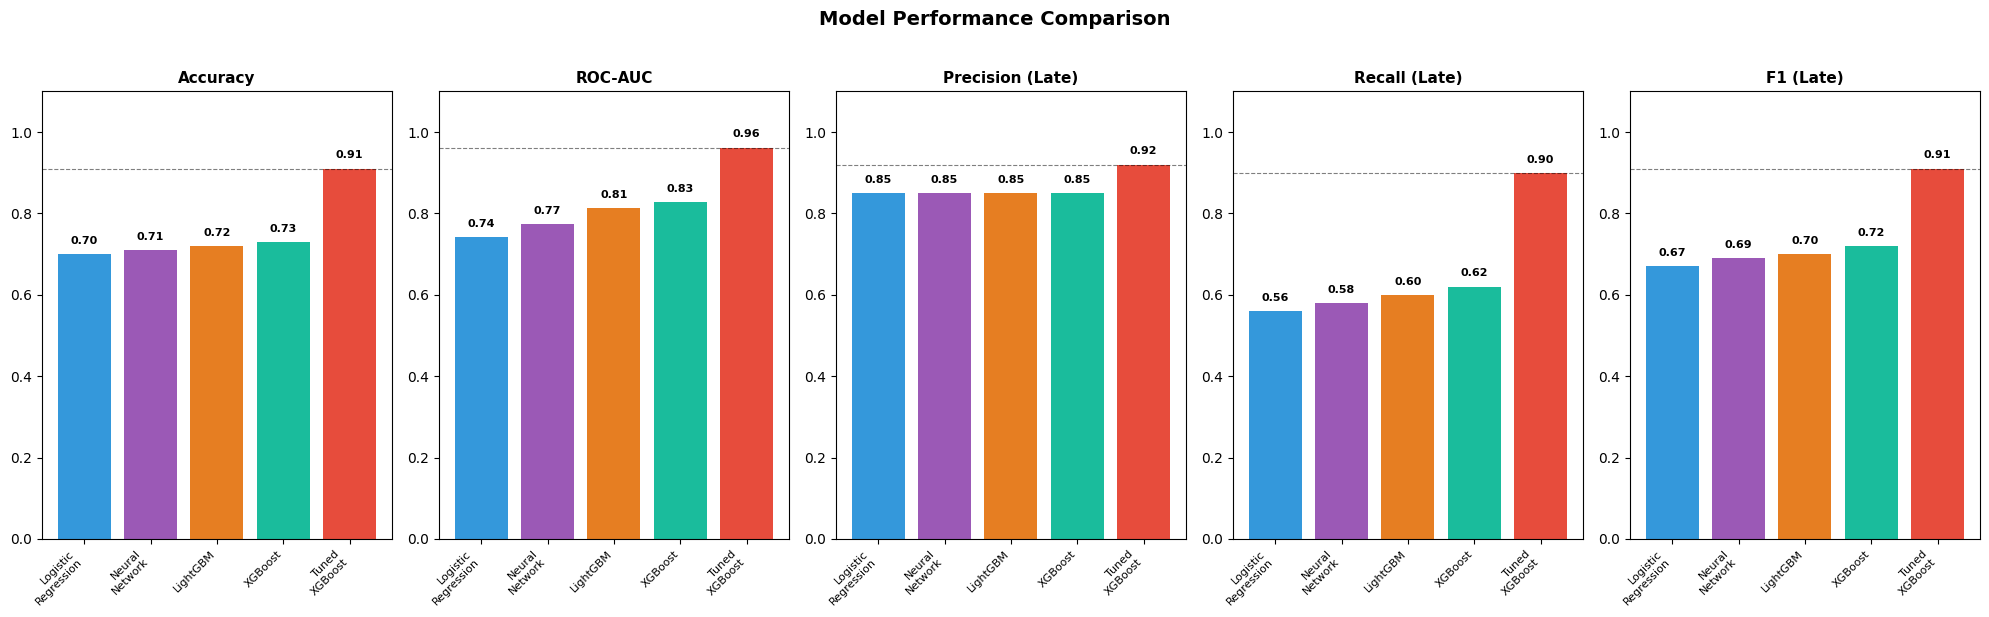

In [19]:
models = ['Logistic\nRegression', 'Neural\nNetwork', 'LightGBM', 'XGBoost', 'Tuned\nXGBoost']

metrics = {
    'Accuracy':         [0.70, 0.71, 0.72, 0.73, 0.91],
    'ROC-AUC':          [0.7410, 0.7729, 0.8127, 0.8279, 0.9618],
    'Precision (Late)': [0.85, 0.85, 0.85, 0.85, 0.92],
    'Recall (Late)':    [0.56, 0.58, 0.60, 0.62, 0.90],
    'F1 (Late)':        [0.67, 0.69, 0.70, 0.72, 0.91]
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']

for ax, (metric, values) in zip(axes, metrics.items()):
    bars = ax.bar(models, values, color=colors)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
    ax.axhline(y=max(values), color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Save model

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_xgb, '../models/tuned_xgboost.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']